# Getting Started

Before proceeding, make sure to run the following two cells. 

In [13]:
import os
import re
import matplotlib.pyplot as plt
import lzma
from collections import defaultdict
import pandas as pd

In [15]:
def process_logs(log_dir, label):
    """
    Process all log files in the given directory to extract decision and number of calls.
    """
    results = []
    decision_pattern = re.compile(r"Decision:\s*(\w+)")
    calls_pattern = re.compile(r"Number of calls:\s*(\d+)")

    for filename in os.listdir(log_dir):
        if filename.endswith(".out.xz"):
            filepath = os.path.join(log_dir, filename)
            x_value = int(filename.split('_')[0])
            with lzma.open(filepath, "rt") as file:
                content = file.read()
                decision_match = decision_pattern.search(content)
                calls_match = calls_pattern.search(content)

                if decision_match and calls_match:
                    decision = decision_match.group(1)
                    num_calls = int(calls_match.group(1))
                    if not (decision == "reject" and num_calls == 0):
                        results.append((x_value, num_calls, label, decision))
    results.sort(key=lambda x: x[0])
    return results


def plot_results(results):
    """
    Plot the results with color per label and shape per decision.

    Args:
        results (list): A list of tuples (x_value, num_calls, label, decision).
        title (str): Title for the plot.
        show (bool): Whether to display the plot immediately.
    """
    colors = {'baseline': 'blue', 'iTester': 'green'}
    rename = {'iTester': r'$\mathsf{Lachesis}$', 'baseline': r'$\mathsf{CubeProbe}$'}
    markers = {'accept': 'o', 'reject': 'x'}
    dec_rename = {'accept': 'Accept', 'reject': 'Reject'}
    
    agg = defaultdict(list)
    for x_value, num_calls, label, decision in results:
        agg[(x_value, label, decision)].append(num_calls)

    plotted_labels = set()
    for (x_value, label, decision), calls in agg.items():
        avg_calls = sum(calls) / len(calls)
        color = colors[label]
        marker = markers[decision]
        display_label = f"{rename[label]} ({dec_rename[decision]})"
        if display_label not in plotted_labels:
            plt.scatter(x_value, avg_calls, color=color, marker=marker, label=display_label, s=100)
            plotted_labels.add(display_label)
        else:
            plt.scatter(x_value, avg_calls, color=color, marker=marker, s=100)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel("Program Domain Size", fontsize=20)
    plt.ylabel(r"#$\mathsf{ICOND}$ Queries", fontsize=20)
    plt.xlim(0, max(x[0] for x in results) + 1)
    plt.yscale('log')
    plt.gcf().set_size_inches(10, 6)
    plt.grid(True)
    plt.legend(loc="center right", fontsize=16)

# Performance Experiment

This section evaluates the runtime performance and sample efficiency of **Lachesis** compared to baseline methods such as **CubeProbe**. We run both algorithms across a suite of benchmark instances, recording total runtime and the number of sampler queries made. The logs are explictly availabe at `./logs/out-14971133-0` (Lachesis) and `./logs/out-14971133-1` (Cubeprobe).

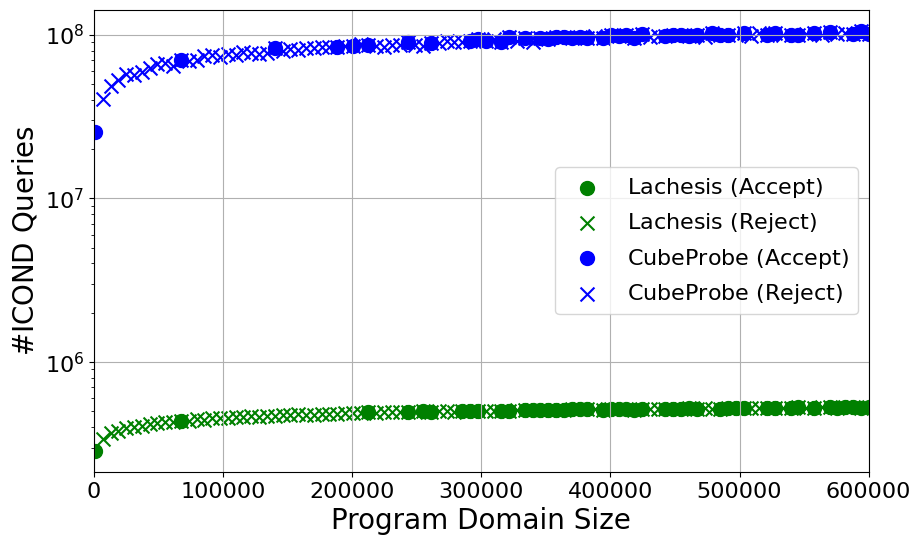

In [16]:
log_dir_1 = "./logs/out-14971133-1"
log_dir_0 = "./logs/out-14971133-0"

results_1 = process_logs(log_dir_1, "iTester")
results_0 = process_logs(log_dir_0, "baseline")

if results_1 and results_0:
    plt.figure(figsize=(10, 6))
    plot_results(results_1 + results_0)
    plt.show()

# Case Study

We perform a focused evaluation of **Lachesis** on the **Binomial** and **Poisson** distributions, including their buggy implementations. These experiments demonstrate Lachesis' effectiveness in detecting deviations from the ideal sampler behavior.


#### Poisson Case Study

This experiment covers the ideal Poisson sampler and several buggy implementations.

- **Logs**: `./logs/out-14891486-*`


In [17]:
# Setup
dir_prefix = "./logs/out-14891486-"
num_dirs = 6
file_pattern = re.compile(r'.*\.out\.xz$')
decision_pattern = re.compile(r'Decision:\s+(accept|reject)', re.IGNORECASE)
calls_pattern = re.compile(r'Number of calls:\s+(\d+)')

# Store results: key -> [(decision, calls), ..., ]
results = defaultdict(lambda: [("", "")] * num_dirs)

# Parse directories
for i in range(1, num_dirs + 1):
    dir_name = f"{dir_prefix}{i}"
    if not os.path.isdir(dir_name):
        continue

    for file in os.listdir(dir_name):
        match = file_pattern.match(file)
        if not match:
            continue

        param_key = match.group(0)
        file_path = os.path.join(dir_name, file)

        with lzma.open(file_path, 'rt') as f:
            content = f.read()

            decision_match = decision_pattern.search(content)
            calls_match = calls_pattern.search(content)

            decision = decision_match.group(1).lower() if decision_match else "N/A"
            calls = calls_match.group(1) if calls_match else "N/A"

            result_list = list(results[param_key])
            result_list[i - 1] = (decision, calls)
            results[param_key] = result_list

# Extract `mu` from filename (assumes filename starts with mu value)
def extract_mu(key):
    return int(key.split('_')[0])  # First part before '_'

# Sort by mu
sorted_keys = sorted(results, key=extract_mu)

# Create a DataFrame
rows = []
for key in sorted_keys:
    mu = extract_mu(key)
    row = {'mu': mu}
    for i, (decision, calls) in enumerate(results[key], 1):
        row[f'dec_{i}'] = decision
        row[f'calls_{i}'] = calls
    rows.append(row)

df_full = pd.DataFrame(rows)
df_full = df_full.sort_values(by='mu')

# Display full table
print("### Full Table")
display(df_full)


### Full Table


,mu,dec_1,calls_1,dec_2,calls_2,dec_3,calls_3,dec_4,calls_4,dec_5,calls_5,dec_6,calls_6
0,1000,accept,811562,reject,833237,reject,842044,reject,140369,reject,808156,accept,800560
1,3020,accept,863672,reject,903475,reject,895914,reject,233807,accept,863148,accept,861109
2,5040,accept,885827,reject,931999,reject,926929,reject,390081,accept,888461,accept,880820
3,7061,accept,911888,reject,955740,reject,942692,reject,546425,accept,905637,accept,898524
4,9081,accept,920237,reject,958480,reject,960679,reject,702723,accept,923127,accept,923894
5,11102,accept,922181,reject,969748,reject,964924,reject,859039,accept,932612,accept,927106
6,13122,accept,931155,reject,974499,reject,981279,reject,1015323,accept,935503,accept,941698
7,15142,accept,943013,reject,991821,reject,988694,reject,1171595,accept,937303,accept,944408
8,17163,accept,952475,reject,991288,reject,990015,reject,1327975,accept,952689,accept,945392
9,19183,accept,954159,reject,1000092,reject,995948,reject,1484249,accept,962597,accept,953944



#### Binomial Case Study

This experiment evaluates both the correct and buggy versions of the Binomial sampler.

- **Logs**: `./logs/out-14889905-*`


In [18]:
# Updated directory prefix
dir_prefix = "./logs/out-14889905-"
num_dirs = 6

# Patterns
file_pattern = re.compile(r'(\d+)_([\d.]+)_(\d+)_([\d.]+)\.out\.xz$')
decision_pattern = re.compile(r'Decision:\s+(accept|reject)', re.IGNORECASE)
calls_pattern = re.compile(r'Number of calls:\s+(\d+)')

# Data store: key -> [(decision, calls), ..., ]
results = defaultdict(lambda: [("", "")] * num_dirs)

# Parse directories
for i in range(1, num_dirs + 1):
    dir_name = f"{dir_prefix}{i}"
    if not os.path.isdir(dir_name):
        continue

    for file in os.listdir(dir_name):
        match = file_pattern.match(file)
        if not match:
            continue

        n1, p1, n2, p2 = match.groups()
        key = (int(n1), float(p1), int(n2), float(p2))
        file_path = os.path.join(dir_name, file)

        with lzma.open(file_path, 'rt') as f:
            content = f.read()

        decision_match = decision_pattern.search(content)
        calls_match = calls_pattern.search(content)

        decision = decision_match.group(1).lower() if decision_match else "N/A"
        calls = calls_match.group(1) if calls_match else "N/A"

        result_list = list(results[key])
        result_list[i - 1] = (decision, calls)
        results[key] = result_list

# Build DataFrame
rows = []
for (n1, p1, n2, p2), outcome_list in sorted(results.items()):
    row = {'n': n1, 'p': p1}
    for i, (decision, calls) in enumerate(outcome_list, 1):
        row[f'dec_{i}'] = decision
        row[f'calls_{i}'] = calls
    rows.append(row)

df = pd.DataFrame(rows)

# Display full table
display(df)


,n,p,dec_1,calls_1,dec_2,calls_2,dec_3,calls_3,dec_4,calls_4,dec_5,calls_5,dec_6,calls_6
0,1000,0.01,accept,31588,reject,38349,reject,6429122,reject,6042867,reject,6042726,reject,6042572
1,3020,0.02,reject,33391,accept,32137,reject,8799659,reject,20122177,reject,20122181,reject,20117736
2,5040,0.03,accept,35658,accept,37115,reject,9692837,reject,9902559,reject,9902559,reject,9912005
3,7061,0.04,accept,38292,reject,37776,reject,10085947,reject,10237109,reject,10237109,reject,10243369
4,9081,0.05,accept,37412,reject,34009,reject,10276355,reject,10397377,reject,10397377,reject,10397377
5,11102,0.06,accept,38726,reject,35105,reject,10366377,reject,10466423,reject,10466423,reject,10466423
6,13122,0.07,accept,39969,reject,34542,reject,10395893,reject,10480787,reject,10480787,reject,10483593
7,15142,0.08,accept,40765,reject,37233,reject,10388991,reject,10463841,reject,10463841,reject,10466163
8,17163,0.09,accept,41708,reject,37205,reject,10357631,reject,10426343,reject,10426343,reject,10426343
9,19183,0.10,accept,40261,reject,34950,reject,10308467,reject,10371085,reject,10371085,reject,10371085
